# Exploratory Data Analysis

In [54]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Define base Path (parent) -- '/Users/nathandouieb/Desktop/TestProdV1'
BASE_DIR = Path.cwd().parent

# Define data Path -- '/Users/nathandouieb/Desktop/TestProdV1/data/riceClassification.csv'
DATA_PATH = BASE_DIR / 'data' / 'riceClassification.csv'
YAML_PATH = BASE_DIR / 'config.yaml'

# Import Yaml
with open(file = YAML_PATH, mode = 'r') as f: config = yaml.safe_load(f)

In [55]:
data = pd.read_csv(DATA_PATH).drop('id', axis = 1)
original_data = data.copy()
print(data.shape)
data.head(3)

(18185, 11)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1


In [56]:
data.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,7036.492989,151.680754,59.807851,0.915406,7225.817872,94.132952,0.616653,351.606949,0.707998,2.599081,0.549079
std,1467.197150,12.376402,10.061653,0.030575,1502.006571,9.906250,0.104389,29.500620,0.067310,0.434836,0.497599
min,2522.000000,74.133114,34.409894,0.676647,2579.000000,56.666658,0.383239,197.015000,0.174590,1.358128,0.000000
25%,5962.000000,145.675910,51.393151,0.891617,6125.000000,87.126656,0.538530,333.990000,0.650962,2.208527,0.000000
50%,6660.000000,153.883750,55.724288,0.923259,6843.000000,92.085696,0.601194,353.088000,0.701941,2.602966,1.000000
75%,8423.000000,160.056214,70.156593,0.941372,8645.000000,103.559146,0.695664,373.003000,0.769280,2.964101,1.000000
max,10210.000000,183.211434,82.550762,0.966774,11008.000000,114.016559,0.886573,508.511000,0.904748,3.911845,1.000000


### Target Distribution

In [58]:
data.Class.value_counts(normalize = True)

Class
1    0.549079
0    0.450921
Name: proportion, dtype: float64

In [61]:
train_data, val_data = train_test_split(data, 
                                        stratify = data.Class, 
                                        test_size = config['split']['VALID_SIZE'], 
                                        random_state = 42)

val_data, test_data = train_test_split(val_data, 
                                       stratify = val_data.Class, 
                                       test_size = config['split']['TEST_SIZE'], 
                                       random_state = 42)

# Checking that we have the same distribution
print('Train Data Target Distribution', train_data.Class.value_counts(normalize = True), '\n')
print('Eval Data Target Distribution', val_data.Class.value_counts(normalize = True), '\n')
print('Test Data Target Distribution', test_data.Class.value_counts(normalize = True), '\n')

Train Data Target Distribution Class
1    0.549079
0    0.450921
Name: proportion, dtype: float64 

Eval Data Target Distribution Class
1    0.548955
0    0.451045
Name: proportion, dtype: float64 

Test Data Target Distribution Class
1    0.549203
0    0.450797
Name: proportion, dtype: float64 



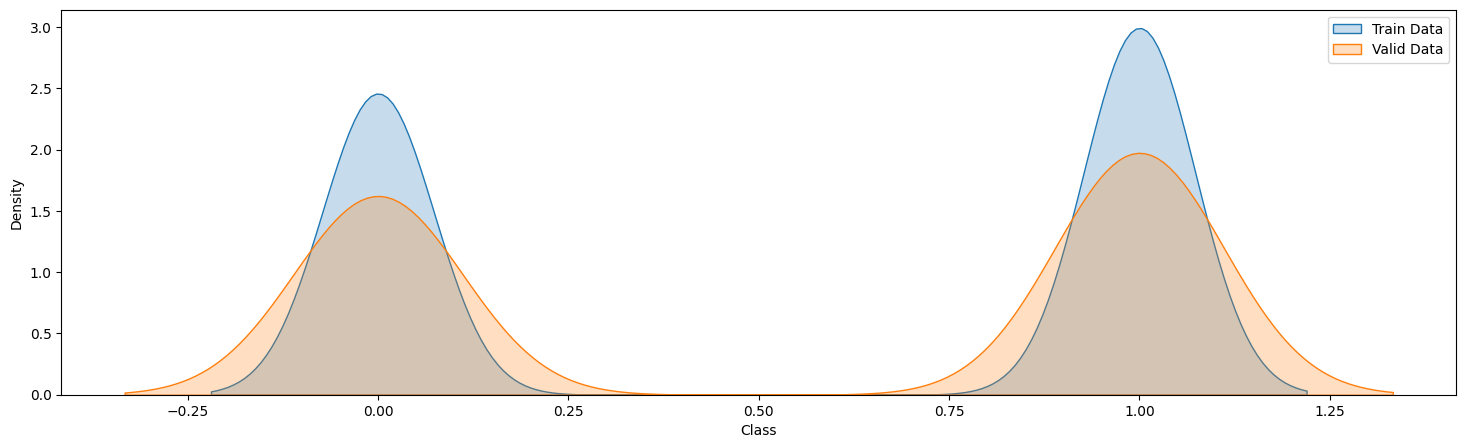

In [71]:
plt.figure(figsize = (18, 5))
sns.kdeplot(data = train_data, x = 'Class', fill = True, label = 'Train Data')
sns.kdeplot(data = val_data, x = 'Class', fill = True, label = 'Valid Data')
plt.legend()
plt.show()

In [ ]:
from typing import Optional

def featuresDistribution(data: pd.DataFrame, column: str, column2: Optional[str] = None) -> None:
    plt.figure(figsize = (18, 5))
    sns.kdeplot(data = data, x = column, fill = True)
    if column2 is not None:
        sns.kdeplot(data = data, x = column2, fill = True, color = 'salmon')
    plt.show()

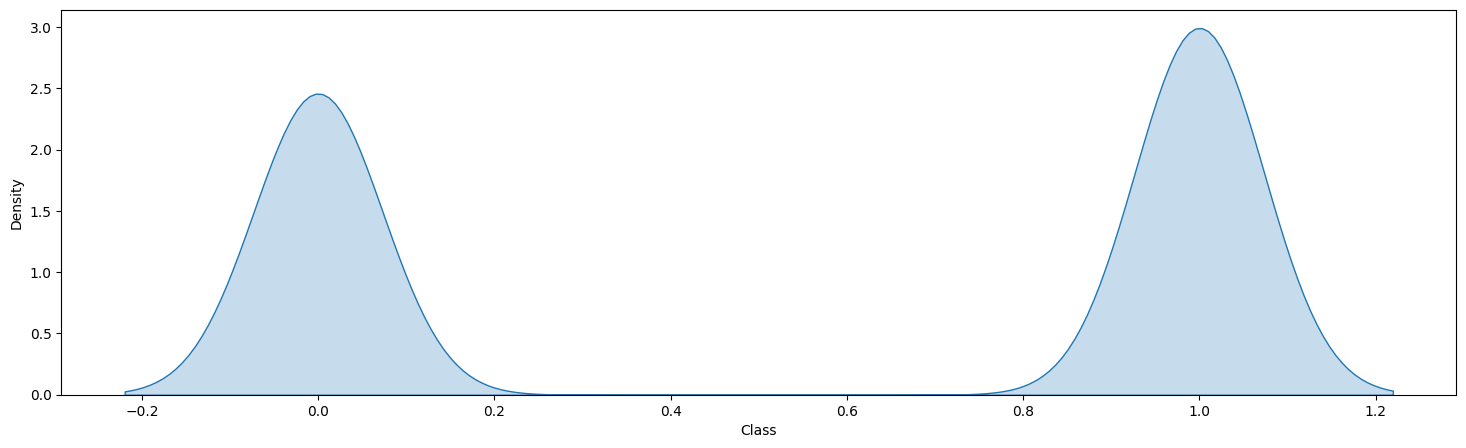

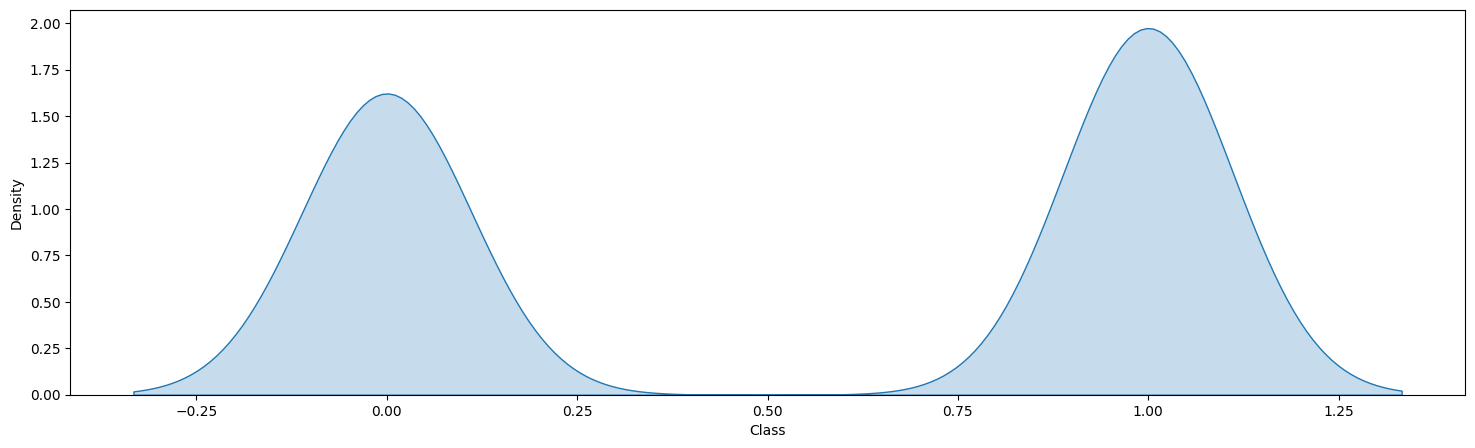

In [63]:
featuresDistribution(data = train_data, column = 'Class')
featuresDistribution(data = val_data, column = 'Class')

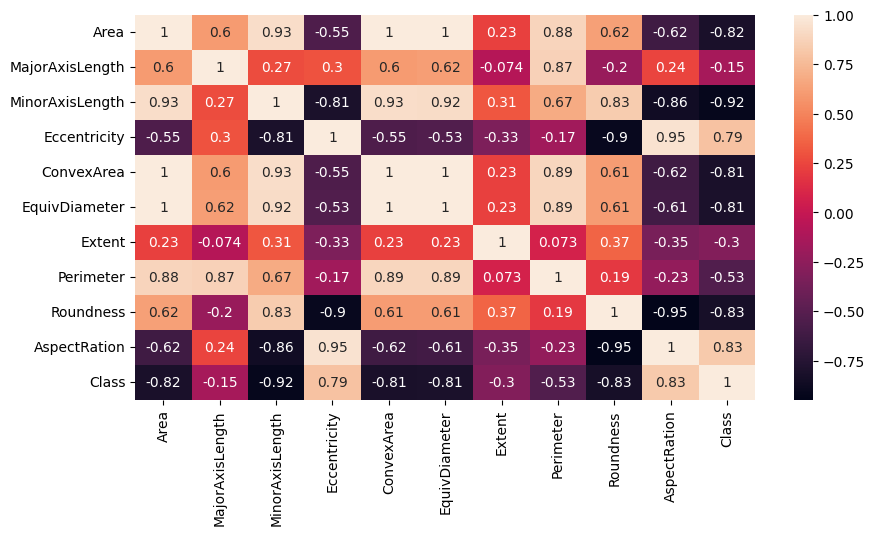

In [ ]:
plt.figure(figsize = (10, 5))
sns.heatmap(data.corr(), annot = True)
plt.show()

## Standardization

**Rappel :** **TOUJOURS** séparer les données (Train/Val/Test) AVANT d'appliquer notre normalisation. 

Si nous calculons la moyenne et l'écart-type sur le dataset entier, les informations de nos données vont "fuiter" dans notre training-set. C'est ce qu'on appelle la `Data Leakage` (fuite de données). Notre modèle va tricher, car il aura indirectement eu accès à des indices sur les données qu'il est censé découvrir plus tard, ce qui faussera nos résultats (ton modèle paraîtra meilleur qu'il ne l'est en réalité).

**Utilisation des Differentes Formules**

* **StandardScaler :** Centre les données autour de 0 avec un écart-type de 1. C'est le choix par défaut le plus courant. Il est parfait quand tes données suivent une distribution "normale" (une courbe en cloche) et pour les algorithmes qui mesurent des distances (comme PCA, SVM, Régression Logistique). Le point faible : Il est sensible s'il y a de très gros outliers.

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

* **MinMaxScaler :** Compresse toutes tes valeurs dans une fourchette stricte, généralement entre 0 et 1. Adapté lorsque nous savons qu enos données ont des limites fixes naturelles (par exemple, les pixels d'une image vont de 0 à 255) ou que nous utilisons des Réseaux de Neurones qui préfèrent les petites valeurs positives. Il est terriblement sensible aux outliers.

$$x_{\text{scaled}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

* **RobustScaler :** Identique a StandardScaler, mais au lieu d'utiliser la moyenne, il utilise la médiane, et au lieu de l'écart-type, il utilise l'écart interquartile (les 50% des données au centre). Il est bon de l'utiliser lorsque notre dataset est bourré de valeurs aberrantes. Le RobustScaler va totalement ignorer les valeurs extrêmes lors de son calcul, ce qui permet à la majorité de tes données normales d'être bien mises à l'échelle.

$$x_{\text{scaled}} = \frac{x - Q_2}{Q_3 - Q_1}$$

In [ ]:
def standardization(data: pd.DataFrame) -> pd.DataFrame:
    '''
    Standardization => Z = (X - Mu) / Std
    '''
    cols = data.drop('Class', axis = 1).columns
    data[cols] = (data[cols] - data[cols].mean()) / data[cols].std()
    return data

In [ ]:
data = standardization(data = data)
data

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,-1.703584,-4.803612,0.417915,-6.393762,-1.696942,-1.829999,0.391643,-2.661705,0.839565,-2.663727,1
1,-2.838400,-6.220618,-0.835588,-6.209412,-2.803462,-3.398050,0.923045,-4.857184,1.837165,-2.635346,1
2,-2.718444,-6.091236,-0.771678,-6.024354,-2.725566,-3.213790,1.365084,-4.799728,2.383522,-2.605878,1
3,-2.701405,-6.031407,-0.783108,-5.781419,-2.708921,-3.188053,1.598591,-4.777864,2.409811,-2.565620,1
4,-2.278830,-5.377651,-0.341279,-5.433330,-2.279496,-2.580319,1.463004,-4.110929,2.477263,-2.504576,1
...,...,...,...,...,...,...,...,...,...,...,...
18180,-0.806635,-0.246936,-0.872478,0.778526,-0.810794,-0.788029,-1.130942,-0.632087,-0.661926,0.720855,0
18181,0.373847,1.447371,-0.165598,0.784678,0.386271,0.417892,0.295123,1.149096,-0.989991,0.730916,0
18182,-0.457671,0.250180,-0.685749,0.796528,-0.462593,-0.414868,-0.530373,-0.317076,-0.373889,0.750431,0
18183,-0.733707,-0.022852,-0.828219,0.818336,-0.690289,-0.708736,-1.190289,-0.279179,-1.081136,0.786813,0


## Cross-Validation